In [3]:
import os
import sys
from pathlib import Path
import random
import numpy as np
import torch

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import degree

# -------------------------
# Repro / device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)

# -------------------------
# Ensure repo root on sys.path (so `import bcosgnn` works)
# -------------------------
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))
print('Repo root added:', repo_root)

/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = cpu
Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [4]:
# -------------------------
# Load custom BA2Motif dataset list
# -------------------------
RAW_DATA_PATH = "/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt"
assert os.path.exists(RAW_DATA_PATH), f"Missing file: {RAW_DATA_PATH}"
print('Loading:', RAW_DATA_PATH)

# Enforce loading to CPU
dataset_list = torch.load(RAW_DATA_PATH, map_location='cpu', weights_only=False)
print('Graphs loaded:', len(dataset_list))
assert isinstance(dataset_list, (list, tuple)) and len(dataset_list) > 0

# If labels are missing, assign first half=0, second half=1 (matches prior BA2Motif scripts).
for i, data in enumerate(dataset_list):
    # Ensure all data is definitely on CPU
    data = data.cpu()
    dataset_list[i] = data

    if not hasattr(data, 'y') or data.y is None or data.y.numel() == 0:
        data.y = torch.tensor([0 if i < (len(dataset_list) // 2) else 1], dtype=torch.long)
    else:
        # Re-assigning .to(torch.long) typically preserves device, but data is CPU now
        data.y = data.y.view(-1).to(torch.long)
        if data.y.numel() == 1:
            data.y = data.y.view(1)
        else:
            # graph-level label: keep first entry if provided oddly
            data.y = data.y[:1]

# Build node features from (clamped) degree one-hot so vanilla GIN has non-trivial inputs.
def add_degree_onehot_x(data: Data, max_degree: int = 4) -> Data:
    row, col = data.edge_index
    deg = degree(col, data.num_nodes, dtype=torch.long).clamp(max=max_degree)
    data.x = torch.nn.functional.one_hot(deg, num_classes=max_degree + 1).to(torch.float)
    return data

for i in range(len(dataset_list)):
    # Only add node features, no edge attributes for GIN
    dataset_list[i] = add_degree_onehot_x(dataset_list[i])
    # Remove edge_attr if it exists to ensure GNNExplainer doesn't get confused
    if hasattr(dataset_list[i], 'edge_attr'):
        del dataset_list[i].edge_attr

# Basic dataset stats
ys = torch.cat([d.y for d in dataset_list]).view(-1)
num_classes = int(torch.unique(ys).numel())
in_dim = int(dataset_list[0].x.size(-1))

print('num_classes =', num_classes)
print('node feature dim =', in_dim)
print('edge feature dim = N/A (GIN)')

Loading: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt
Graphs loaded: 1000
num_classes = 2
node feature dim = 5
edge feature dim = N/A (GIN)
num_classes = 2
node feature dim = 5
edge feature dim = N/A (GIN)


In [5]:
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from torch_geometric.nn import GINConv, global_add_pool

class VanillaGIN4(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, num_classes: int, drop_ratio: float = 0.5):
        super().__init__()
        self.node_proj = Linear(in_dim, hidden_dim)

        def mlp():
            return Sequential(
                Linear(hidden_dim, 2 * hidden_dim),
                BatchNorm1d(2 * hidden_dim),
                ReLU(),
                Linear(2 * hidden_dim, hidden_dim),
            )

        self.conv1 = GINConv(nn=mlp(), train_eps=True)
        self.bn1 = BatchNorm1d(hidden_dim)
        self.conv2 = GINConv(nn=mlp(), train_eps=True)
        self.bn2 = BatchNorm1d(hidden_dim)
        self.conv3 = GINConv(nn=mlp(), train_eps=True)
        self.bn3 = BatchNorm1d(hidden_dim)
        self.conv4 = GINConv(nn=mlp(), train_eps=True)
        self.bn4 = BatchNorm1d(hidden_dim)

        self.drop_ratio = drop_ratio
        self.classifier = Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch=None, edge_attr=None):
        # Arguments ordered: batch first (after edge_index), then edge_attr
        # This supports positional calls: model(x, ei, batch)
        # And keyword calls from Explainer: model(x, ei, ..., edge_attr=ea)
        
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        h = self.node_proj(x.float())

        h = F.relu(self.bn1(self.conv1(h, edge_index)))
        h = F.relu(self.bn2(self.conv2(h, edge_index)))
        h = F.relu(self.bn3(self.conv3(h, edge_index)))
        h = F.relu(self.bn4(self.conv4(h, edge_index)))

        hg = global_add_pool(h, batch)
        hg = F.dropout(hg, p=self.drop_ratio, training=self.training)
        return self.classifier(hg)

# Model instantiation moved to Experiment Loop
# model = VanillaGIN4(in_dim=in_dim, hidden_dim=64, num_classes=num_classes, drop_ratio=0.5).to(DEVICE)


In [6]:
from copy import deepcopy
from tqdm import tqdm
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(DEVICE)
        if batch.num_nodes <= 1:
            continue

        # GIN does not use edge_attr
        logits = model(batch.x, batch.edge_index, batch.batch)
        y = batch.y.view(-1).to(torch.long)

        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * int(batch.num_graphs)
        pred = logits.argmax(dim=-1)
        total_correct += int((pred == y).sum().item())
        total_graphs += int(batch.num_graphs)

    return (total_loss / max(total_graphs, 1)), (total_correct / max(total_graphs, 1))

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(DEVICE)
        if batch.num_nodes <= 1:
            continue

        logits = model(batch.x, batch.edge_index, batch.batch)
        y = batch.y.view(-1).to(torch.long)
        loss = criterion(logits, y)

        total_loss += float(loss.item()) * int(batch.num_graphs)
        pred = logits.argmax(dim=-1)
        total_correct += int((pred == y).sum().item())
        total_graphs += int(batch.num_graphs)

    return (total_loss / max(total_graphs, 1)), (total_correct / max(total_graphs, 1))



In [7]:
indices = np.arange(len(dataset_list))
n = len(indices)
n_train = int(0.8 * n)
n_val = int(0.1 * n)
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

train_dataset = [dataset_list[i] for i in train_idx]
val_dataset = [dataset_list[i] for i in val_idx]
test_dataset = [dataset_list[i] for i in test_idx]

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Initialize Model
model = VanillaGIN4(in_dim=in_dim, hidden_dim=64, num_classes=num_classes, drop_ratio=0.5).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

# 4. Train
EPOCHS = 100
EARLY_STOP_PATIENCE = 25
best_val_loss = float('inf')
best_state = None
epochs_no_improve = 0

for epoch in tqdm(range(1, EPOCHS + 1)):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        
    if epoch % 50 == 0:
            print(f"  Epoch {epoch:03d}: val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"  Early stopping at epoch {epoch}")
        break
        
if best_state is not None:
    model.load_state_dict(best_state)

test_loss, test_acc = eval_one_epoch(model, test_loader, criterion)
print(f"  Best Val Loss: {best_val_loss:.4f} | Test Acc: {test_acc:.4f}")
print(f"Test Loss : {test_loss:.4f}, Test Acc: {test_acc:.4f}")



 30%|███       | 30/100 [00:04<00:09,  7.42it/s]

  Early stopping at epoch 31
  Best Val Loss: 0.0000 | Test Acc: 1.0000
Test Loss : 0.0000, Test Acc: 1.0000


In [8]:
import random
import numpy as np
import torch
from tqdm import tqdm
from torch_geometric.explain import Explainer, CaptumExplainer, ModelConfig
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------
# 1. Setup IG Explainer
# ---------------------------------------------------------
ig_explainer = Explainer(
    model=model,
    algorithm=CaptumExplainer('IntegratedGradients'),
    explanation_type='model',
    model_config=ModelConfig(
        mode='multiclass_classification',
        task_level='graph',
        return_type='probs',
    ),
    node_mask_type='attributes',
    edge_mask_type=None,
)

# ---------------------------------------------------------
# 2. Evaluation & Inspection Function
# ---------------------------------------------------------
def evaluate_and_inspect_ig(loader, model, device, show_samples=5):
    model.eval()
    
    all_jaccards = []
    all_aurocs = []
    
    # Handle both DataLoader and List[Data]
    dataset = loader.dataset if hasattr(loader, 'dataset') else loader
    
    # Select random indices to inspect
    inspect_indices = set(random.sample(range(len(dataset)), show_samples))
    
    print(f"Evaluating IG on {len(dataset)} graphs...")
    
    for i, data in enumerate(tqdm(dataset)):
        data = data.to(device)
        
        # A. Prediction
        logits = model(data.x, data.edge_index, batch=data.batch)
        pred_label = logits.argmax(dim=-1).item()
        
        # B. Explanation
        explanation = ig_explainer(
            x=data.x,
            edge_index=data.edge_index,
            batch=data.batch,
            target=pred_label
        )
        
        # C. Aggregate Feature Mask -> Node Mask
        # Sum absolute attribution across features
        node_attr = explanation.node_mask.abs().sum(dim=1)
        
        # D. Normalize (0 to 1) per graph
        if node_attr.max() > node_attr.min():
            pred_mask = (node_attr - node_attr.min()) / (node_attr.max() - node_attr.min())
        else:
            pred_mask = torch.zeros_like(node_attr)
            
        # E. Get Ground Truth
        if hasattr(data, 'node_mask'):
            gt_mask = data.node_mask.cpu().numpy().astype(int)
        elif hasattr(data, 'explanation_mask'):
            gt_mask = data.explanation_mask.cpu().numpy().astype(int)
        else:
            continue # Skip if no GT
            
        pred_mask_np = pred_mask.detach().cpu().numpy()
        
        # F. Metrics
        # Node AUROC
        try:
            if len(np.unique(gt_mask)) > 1:
                all_aurocs.append(roc_auc_score(gt_mask, pred_mask_np))
        except: pass

        # Node Jaccard (Threshold 0.5)
        pred_binary = (pred_mask_np > 0.5).astype(int)
        intersect = (pred_binary & gt_mask).sum()
        union = (pred_binary | gt_mask).sum()
        all_jaccards.append(intersect / (union + 1e-8) if union > 0 else 0.0)
        
        # G. Print Samples (Requested Feature)
        if i in inspect_indices:
            print(f"\n{'-'*20} Graph {i} Inspection {'-'*20}")
            print(f"GT Class: {data.y.item()} | Pred Class: {pred_label}")
            print(f"GT Mask:   {gt_mask}")
            print(f"Pred Mask: {np.round(pred_mask_np, 2)}") # Rounded for readability
            print(f"Graph Jaccard: {all_jaccards[-1]:.4f}")

    return np.mean(all_jaccards), np.mean(all_aurocs)

# ---------------------------------------------------------
# 3. Run
# ---------------------------------------------------------
ig_jaccard, ig_auroc = evaluate_and_inspect_ig(test_dataset, model, DEVICE, show_samples=5)

print("\n" + "="*40)
print(f"FINAL IG RESULTS")
print("="*40)
print(f"Avg Node Jaccard: {ig_jaccard:.4f}")
print(f"Avg Node AUROC:   {ig_auroc:.4f}")

Evaluating IG on 100 graphs...


  0%|          | 0/100 [00:00<?, ?it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  2%|▏         | 2/100 [00:00<00:07, 13.70it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  2%|▏         | 2/100 [00:00<00:07, 13.70it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarni


-------------------- Graph 3 Inspection --------------------
GT Class: 1 | Pred Class: 1
GT Mask:   [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
Pred Mask: [0.84 0.05 0.33 0.02 0.28 0.06 0.05 0.19 0.05 0.24 0.   0.33 0.2  0.33
 0.06 0.06 0.   0.   0.05 0.06 1.   1.   0.03 0.03 0.96]
Graph Jaccard: 0.5000


/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  8%|▊         | 8/100 [00:00<00:06, 14.90it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation


-------------------- Graph 14 Inspection --------------------
GT Class: 1 | Pred Class: 1
GT Mask:   [0 0 0 0 0 0 1 1 1 1 1]
Pred Mask: [0.   0.04 0.46 0.04 0.08 0.08 1.   1.   0.1  0.1  0.84]
Graph Jaccard: 0.6000


...


-------------------- Graph 81 Inspection --------------------
GT Class: 1 | Pred Class: 1
GT Mask:   [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
Pred Mask: [0.12 0.15 0.26 0.03 0.09 0.   0.21 0.04 0.03 0.06 0.03 0.03 0.08 0.
 0.01 0.   0.07 0.03 0.   0.05 0.03 0.   0.   0.   0.08 1.   0.96 0.24
 0.79 0.16]
Graph Jaccard: 0.6000


/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
 86%|████████▌ | 86/100 [00:05<00:00, 14.65it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanatio


-------------------- Graph 94 Inspection --------------------
GT Class: 1 | Pred Class: 1
GT Mask:   [0 0 0 0 0 0 1 1 1 1 1]
Pred Mask: [0.13 0.   0.03 0.   0.32 0.   1.   0.22 0.49 0.39 0.7 ]
Graph Jaccard: 0.4000


/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/3719891774.py:49: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
100%|██████████| 100/100 [00:06<00:00, 15.52it/s]


FINAL IG RESULTS
Avg Node Jaccard: 0.5193
Avg Node AUROC:   0.8934


/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/2524331847.py:45: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(


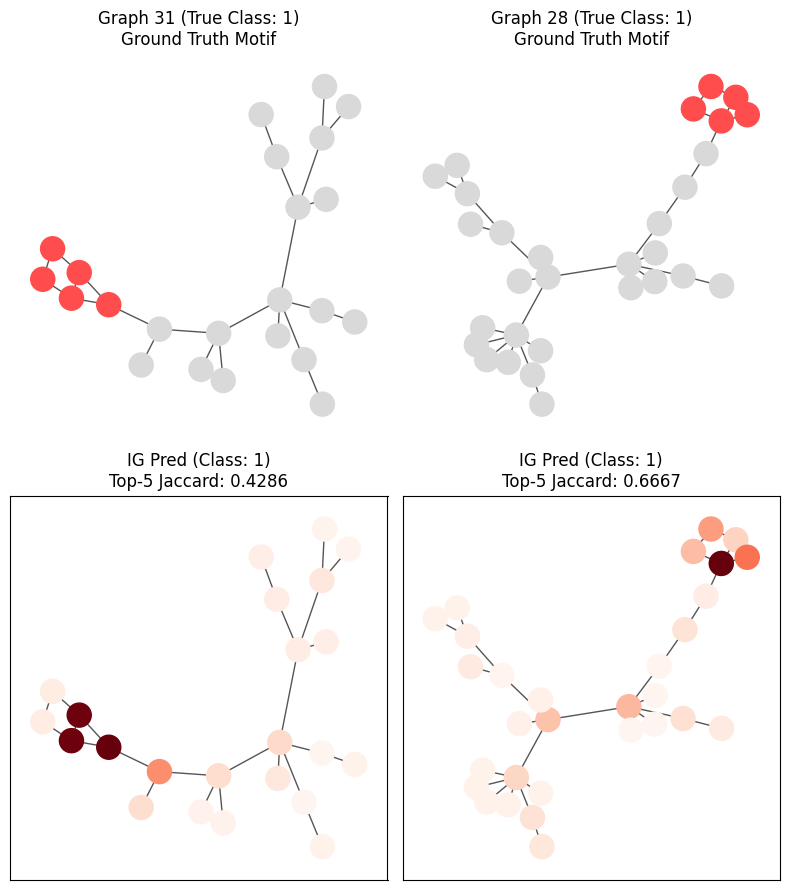

In [9]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
import random
from collections import defaultdict

def visualize_ig_top_k(dataset, model, explainer, k=5, samples_per_class=2, device='cpu'):
    model.eval()
    
    # 1. Group indices by class
    class_indices = defaultdict(list)
    for idx, data in enumerate(dataset):
        y = data.y.item()
        class_indices[y].append(idx)
        
    # 2. Select samples (2 per class)
    selected_indices = []
    sorted_classes = sorted(class_indices.keys())
    
    for c in sorted_classes:
        # Pick random samples for this class
        indices = class_indices[c]
        if len(indices) >= samples_per_class:
            selected = random.sample(indices, samples_per_class)
        else:
            selected = indices # Take all if not enough
        selected_indices.extend(selected)
        
    num_plots = len(selected_indices)
    
    # Setup Plot: 2 Rows, 'num_plots' Columns
    fig, axes = plt.subplots(2, num_plots, figsize=(4 * num_plots, 9))
    
    # Handle single sample case (axes logic)
    if num_plots == 1:
        axes = axes.reshape(2, 1)
    
    for i, idx in enumerate(selected_indices):
        data = dataset[idx].to(device)
        
        # --- A. Run Explainer ---
        logits = model(data.x, data.edge_index, batch=data.batch)
        pred_label = logits.argmax(dim=-1).item()
        
        explanation = explainer(
            x=data.x, 
            edge_index=data.edge_index, 
            batch=data.batch,
            target=pred_label
        )
        
        # Process Scores: Sum absolute -> Top-K Binary Mask
        node_attr = explanation.node_mask.abs().sum(dim=1)
        
        # Normalize for Visualization (Continuous Color)
        if node_attr.max() > node_attr.min():
            viz_scores = (node_attr - node_attr.min()) / (node_attr.max() - node_attr.min())
        else:
            viz_scores = torch.zeros_like(node_attr)
        viz_scores = viz_scores.detach().cpu().numpy()
        
        # Create Binary Mask for Top-K Jaccard
        num_nodes = data.num_nodes
        effective_k = min(k, num_nodes)
        
        # Get indices of top k scores
        _, top_indices = torch.topk(node_attr, effective_k)
        
        pred_binary = torch.zeros(num_nodes, device=device)
        pred_binary[top_indices] = 1.0
        pred_binary_np = pred_binary.cpu().numpy()
        
        # --- B. Get Ground Truth & Calc Jaccard ---
        if hasattr(data, 'node_mask'):
            gt_mask = data.node_mask.cpu().numpy()
        elif hasattr(data, 'explanation_mask'):
            gt_mask = data.explanation_mask.cpu().numpy()
        else:
            gt_mask = np.zeros(num_nodes)
            
        # Jaccard Calculation
        intersect = (pred_binary_np * gt_mask).sum()
        union = (pred_binary_np + gt_mask).clip(0, 1).sum()
        jaccard = intersect / (union + 1e-8) if union > 0 else 0.0

        # --- C. Plotting ---
        G = to_networkx(data, to_undirected=True)
        pos = nx.spring_layout(G, seed=42)
        
        # Row 1: Ground Truth
        ax_gt = axes[0, i]
        node_colors_gt = ['#ff4d4d' if m == 1 else '#d9d9d9' for m in gt_mask]
        nx.draw(G, pos, ax=ax_gt, node_color=node_colors_gt, 
                node_size=300, edge_color='#555555', width=1.0, with_labels=False)
        ax_gt.set_title(f"Graph {idx} (True Class: {data.y.item()})\nGround Truth Motif")
        
        # Row 2: Prediction
        ax_pred = axes[1, i]
        im = nx.draw_networkx_nodes(G, pos, ax=ax_pred, node_color=viz_scores, 
                                    cmap='Reds', node_size=300, vmin=0, vmax=1)
        nx.draw_networkx_edges(G, pos, ax=ax_pred, edge_color='#555555', width=1.0)
        
        ax_pred.set_title(f"IG Pred (Class: {pred_label})\nTop-{k} Jaccard: {jaccard:.4f}")
        
    plt.tight_layout()
    plt.show()

# Run
visualize_ig_top_k(test_dataset, model, ig_explainer, k=5, samples_per_class=2, device=DEVICE)

In [10]:
# -------------------------
# Timing helpers for Integrated Gradients
# -------------------------
import time

def _sync_if_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def _get_batch(data):
    return data.batch if hasattr(data, "batch") else torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE)

def time_ig_explainer_per_graph(ig_explainer, model, dataset, warmup: int = 2, max_graphs: int | None = None):
    """Returns per-graph timing stats (ms) for Integrated Gradients on a dataset list."""
    model.eval()
    times_ms = []
    graphs = dataset[:max_graphs] if max_graphs is not None else dataset

    # Warmup (not timed)
    for data in graphs[:warmup]:
        data = data.to(DEVICE)
        batch = _get_batch(data)
        logits = model(data.x, data.edge_index, batch=batch)
        pred_label = logits.argmax(dim=-1).item()
        _ = ig_explainer(x=data.x, edge_index=data.edge_index, batch=batch, target=pred_label)

    for data in graphs:
        data = data.to(DEVICE)
        batch = _get_batch(data)
        logits = model(data.x, data.edge_index, batch=batch)
        pred_label = logits.argmax(dim=-1).item()
        _sync_if_cuda()
        start = time.perf_counter()
        _ = ig_explainer(x=data.x, edge_index=data.edge_index, batch=batch, target=pred_label)
        _sync_if_cuda()
        end = time.perf_counter()
        times_ms.append((end - start) * 1000)

    times_ms = np.asarray(times_ms, dtype=float)
    mean_ms = float(times_ms.mean()) if times_ms.size else float('nan')
    std_ms = float(times_ms.std()) if times_ms.size else float('nan')
    median_ms = float(np.median(times_ms)) if times_ms.size else float('nan')
    p90_ms = float(np.percentile(times_ms, 90)) if times_ms.size else float('nan')
    graphs_per_s = float(1000.0 / mean_ms) if mean_ms > 0 else float('nan')
    total_s = float(times_ms.sum() / 1000.0) if times_ms.size else float('nan')

    return {
        "mean_ms": mean_ms,
        "std_ms": std_ms,
        "median_ms": median_ms,
        "p90_ms": p90_ms,
        "graphs_per_s": graphs_per_s,
        "total_s": total_s,
        "n_graphs": int(times_ms.size),
    }

In [11]:
import numpy as np
import torch
import random
import time
from copy import deepcopy
from torch_geometric.loader import DataLoader
from torch_geometric.explain import Explainer, CaptumExplainer, ModelConfig
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# Configuration
SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 100
BATCH_SIZE = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Storage for final metrics
final_results = {
    'acc': [],
    'jaccard': [],
    'auroc': []
}
results_ig_time_mean_ms = []
results_ig_time_median_ms = []
results_ig_time_p90_ms = []
results_ig_time_graphs_per_s = []
results_ig_train_time_s = []
results_ig_explain_total_s = []
results_ig_end_to_end_s = []

print(f"Starting 5-Seed IG Experiment on {DEVICE}...")
print("=" * 60)

for run_id, seed in enumerate(SEEDS):
    print(f"RUN {run_id+1}/{len(SEEDS)} | SEED: {seed}")
    
    # -------------------------------------------------
    # 1. Seeding & Data Split
    # -------------------------------------------------
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    # Shuffle dataset indices for random split
    indices = np.arange(len(dataset_list))
    np.random.shuffle(indices)
    
    n_train = int(0.8 * len(indices))
    n_val = int(0.1 * len(indices))
    
    train_idx = indices[:n_train]
    val_idx = indices[n_train : n_train + n_val]
    test_idx = indices[n_train + n_val :]
    
    train_set = [dataset_list[i] for i in train_idx]
    val_set = [dataset_list[i] for i in val_idx]
    test_set = [dataset_list[i] for i in test_idx]
    
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
    
    # -------------------------------------------------
    # 2. Train Model (Fresh Start)
    # -------------------------------------------------
    model = VanillaGIN4(in_dim=in_dim, hidden_dim=64, num_classes=num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()
    
    best_val_acc = 0.0
    best_state = None
    
    _sync_if_cuda()
    train_start = time.perf_counter()
    # Simple training loop
    for epoch in range(EPOCHS):
        # reuse your existing train function
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = eval_one_epoch(model, val_loader, criterion)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
    _sync_if_cuda()
    train_end = time.perf_counter()
    train_time_s = train_end - train_start
    results_ig_train_time_s.append(train_time_s)
    print(f"  Training time: {train_time_s:.2f}s")
            
    # Load best model
    model.load_state_dict(best_state)
    test_loss, test_acc = eval_one_epoch(model, test_loader, criterion)
    final_results['acc'].append(test_acc)
    print(f"  Best Val Acc: {best_val_acc:.4f} | Test Acc: {test_acc:.4f}")

    # -------------------------------------------------
    # 3. Setup Integrated Gradients Explainer
    # -------------------------------------------------
    ig_explainer = Explainer(
        model=model,
        algorithm=CaptumExplainer('IntegratedGradients'),
        explanation_type='model',
        model_config=ModelConfig(
            mode='multiclass_classification',
            task_level='graph',
            return_type='probs',
        ),
        node_mask_type='attributes',
        edge_mask_type=None,
    )
    
    # -------------------------------------------------
    # 4. Evaluation Loop
    # -------------------------------------------------
    model.eval()
    seed_jaccards = []
    seed_aurocs = []
    
    # Iterate through test set (graph by graph for explanations)
    for data in tqdm(test_set, desc="  Explaining", leave=False):
        data = data.to(DEVICE)
        batch = data.batch if hasattr(data, "batch") else torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE)
        
        # Get Pred
        logits = model(data.x, data.edge_index, batch=batch)
        pred_label = logits.argmax(dim=-1).item()
        
        # Explain
        explanation = ig_explainer(
            x=data.x, edge_index=data.edge_index, batch=batch, target=pred_label
        )
        
        # Process Scores
        node_attr = explanation.node_mask.abs().sum(dim=1)
        if node_attr.max() > node_attr.min():
            scores = (node_attr - node_attr.min()) / (node_attr.max() - node_attr.min())
        else:
            scores = torch.zeros_like(node_attr)
        scores_np = scores.detach().cpu().numpy()
        
        # Get GT
        if hasattr(data, 'node_mask'):
            gt_mask = data.node_mask.cpu().numpy().astype(int)
        elif hasattr(data, 'explanation_mask'):
            gt_mask = data.explanation_mask.cpu().numpy().astype(int)
        else:
            continue
            
        # Metrics
        # 1. AUROC (Check if valid for this graph)
        try:
            if len(np.unique(gt_mask)) > 1:
                auc = roc_auc_score(gt_mask, scores_np)
                seed_aurocs.append(auc)
        except:
            pass
        
        # 2. Jaccard (Threshold 0.5)
        pred_binary = (scores_np > 0.5).astype(int)
        intersect = (pred_binary & gt_mask).sum()
        union = (pred_binary | gt_mask).sum()
        jac = intersect / (union + 1e-8) if union > 0 else 0.0
        seed_jaccards.append(jac)
        
    mean_jac = np.mean(seed_jaccards)
    mean_auc = np.mean(seed_aurocs)
    
    final_results['jaccard'].append(mean_jac)
    final_results['auroc'].append(mean_auc)
    print(f"  Metrics -> Jaccard: {mean_jac:.4f} | AUROC: {mean_auc:.4f}")
    
    # 5. Timing (per-graph, end-to-end IG explainer)
    timing = time_ig_explainer_per_graph(
        ig_explainer, model, test_set, warmup=2, max_graphs=None
    )
    results_ig_time_mean_ms.append(timing["mean_ms"])
    results_ig_time_median_ms.append(timing["median_ms"])
    results_ig_time_p90_ms.append(timing["p90_ms"])
    results_ig_time_graphs_per_s.append(timing["graphs_per_s"])
    results_ig_explain_total_s.append(timing["total_s"])
    end_to_end_s = train_time_s + timing["total_s"]
    results_ig_end_to_end_s.append(end_to_end_s)
    print(
        f"  Timing (ms/graph): mean={timing['mean_ms']:.2f}, "
        f"median={timing['median_ms']:.2f}, p90={timing['p90_ms']:.2f} "
        f"| throughput={timing['graphs_per_s']:.2f} graphs/s"
    )
    print(f"  Explain total time: {timing['total_s']:.2f}s | End-to-end: {end_to_end_s:.2f}s")

# -------------------------------------------------
# Final Reporting
# -------------------------------------------------
print("\n" + "="*60)
print("FINAL RESULTS (5 SEEDS)")
print("="*60)
print(f"Test Accuracy: {np.mean(final_results['acc']):.4f} ± {np.std(final_results['acc']):.4f}")
print(f"Node Jaccard:  {np.mean(final_results['jaccard']):.4f} ± {np.std(final_results['jaccard']):.4f}")
print(f"Node AUROC:    {np.mean(final_results['auroc']):.4f} ± {np.std(final_results['auroc']):.4f}")
print(f"IG train time (s): {np.mean(results_ig_train_time_s):.2f} ± {np.std(results_ig_train_time_s):.2f}")
print(f"IG explain total time (s): {np.mean(results_ig_explain_total_s):.2f} ± {np.std(results_ig_explain_total_s):.2f}")
print(f"IG end-to-end time (s): {np.mean(results_ig_end_to_end_s):.2f} ± {np.std(results_ig_end_to_end_s):.2f}")
print(f"IG mean ms/graph: {np.mean(results_ig_time_mean_ms):.2f} ± {np.std(results_ig_time_mean_ms):.2f}")
print(f"IG median ms/graph: {np.mean(results_ig_time_median_ms):.2f} ± {np.std(results_ig_time_median_ms):.2f}")
print(f"IG p90 ms/graph: {np.mean(results_ig_time_p90_ms):.2f} ± {np.std(results_ig_time_p90_ms):.2f}")
print(f"IG throughput (graphs/s): {np.mean(results_ig_time_graphs_per_s):.2f} ± {np.std(results_ig_time_graphs_per_s):.2f}")

Starting 5-Seed IG Experiment on cpu...
RUN 1/5 | SEED: 0
  Training time: 13.20s
  Best Val Acc: 1.0000 | Test Acc: 0.9900
  Training time: 13.20s
  Best Val Acc: 1.0000 | Test Acc: 0.9900


  Explaining:   0%|          | 0/100 [00:00<?, ?it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  Explaining:   2%|▏         | 2/100 [00:00<00:06, 15.22it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  Explaining:   2%|▏         | 2/100 [00:00<00:06, 15.22it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000g

  Metrics -> Jaccard: 0.5804 | AUROC: 0.9162
  Timing (ms/graph): mean=61.97, median=60.97, p90=64.98 | throughput=16.14 graphs/s
  Explain total time: 6.20s | End-to-end: 19.40s
RUN 2/5 | SEED: 1
  Timing (ms/graph): mean=61.97, median=60.97, p90=64.98 | throughput=16.14 graphs/s
  Explain total time: 6.20s | End-to-end: 19.40s
RUN 2/5 | SEED: 1
  Training time: 14.93s
  Best Val Acc: 1.0000 | Test Acc: 1.0000
  Training time: 14.93s
  Best Val Acc: 1.0000 | Test Acc: 1.0000


  Explaining:   0%|          | 0/100 [00:00<?, ?it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  Explaining:   2%|▏         | 2/100 [00:00<00:07, 12.27it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  Explaining:   2%|▏         | 2/100 [00:00<00:07, 12.27it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000g

  Metrics -> Jaccard: 0.3020 | AUROC: 0.8555
  Timing (ms/graph): mean=62.37, median=61.11, p90=65.52 | throughput=16.03 graphs/s
  Explain total time: 6.24s | End-to-end: 21.17s
RUN 3/5 | SEED: 2
  Timing (ms/graph): mean=62.37, median=61.11, p90=65.52 | throughput=16.03 graphs/s
  Explain total time: 6.24s | End-to-end: 21.17s
RUN 3/5 | SEED: 2
  Training time: 12.60s
  Best Val Acc: 1.0000 | Test Acc: 1.0000
  Training time: 12.60s
  Best Val Acc: 1.0000 | Test Acc: 1.0000


...

  Metrics -> Jaccard: 0.6233 | AUROC: 0.9041
  Timing (ms/graph): mean=76.98, median=76.18, p90=80.61 | throughput=12.99 graphs/s
  Explain total time: 7.70s | End-to-end: 20.30s
RUN 4/5 | SEED: 3
  Timing (ms/graph): mean=76.98, median=76.18, p90=80.61 | throughput=12.99 graphs/s
  Explain total time: 7.70s | End-to-end: 20.30s
RUN 4/5 | SEED: 3
  Training time: 18.40s
  Best Val Acc: 1.0000 | Test Acc: 1.0000
  Training time: 18.40s
  Best Val Acc: 1.0000 | Test Acc: 1.0000


  Explaining:   0%|          | 0/100 [00:00<?, ?it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  Explaining:   2%|▏         | 2/100 [00:00<00:08, 11.63it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  Explaining:   2%|▏         | 2/100 [00:00<00:08, 11.63it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000g

  Metrics -> Jaccard: 0.5975 | AUROC: 0.8836
  Timing (ms/graph): mean=75.14, median=75.18, p90=79.91 | throughput=13.31 graphs/s
  Explain total time: 7.51s | End-to-end: 25.91s
RUN 5/5 | SEED: 4
  Timing (ms/graph): mean=75.14, median=75.18, p90=79.91 | throughput=13.31 graphs/s
  Explain total time: 7.51s | End-to-end: 25.91s
RUN 5/5 | SEED: 4
  Training time: 16.81s
  Best Val Acc: 1.0000 | Test Acc: 1.0000
  Training time: 16.81s
  Best Val Acc: 1.0000 | Test Acc: 1.0000


  Explaining:   0%|          | 0/100 [00:00<?, ?it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  Explaining:   2%|▏         | 2/100 [00:00<00:07, 12.53it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_2560/1126463222.py:131: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = ig_explainer(
  Explaining:   2%|▏         | 2/100 [00:00<00:07, 12.53it/s]/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000g

  Metrics -> Jaccard: 0.6269 | AUROC: 0.9038
  Timing (ms/graph): mean=73.48, median=73.30, p90=74.68 | throughput=13.61 graphs/s
  Explain total time: 7.35s | End-to-end: 24.15s

FINAL RESULTS (5 SEEDS)
Test Accuracy: 0.9980 ± 0.0040
Node Jaccard:  0.5460 ± 0.1232
Node AUROC:    0.8927 ± 0.0213
IG train time (s): 15.19 ± 2.17
IG explain total time (s): 7.00 ± 0.65
IG end-to-end time (s): 22.19 ± 2.45
IG mean ms/graph: 69.99 ± 6.48
IG median ms/graph: 69.35 ± 6.85
IG p90 ms/graph: 73.14 ± 6.76
IG throughput (graphs/s): 14.42 ± 1.38
  Timing (ms/graph): mean=73.48, median=73.30, p90=74.68 | throughput=13.61 graphs/s
  Explain total time: 7.35s | End-to-end: 24.15s

FINAL RESULTS (5 SEEDS)
Test Accuracy: 0.9980 ± 0.0040
Node Jaccard:  0.5460 ± 0.1232
Node AUROC:    0.8927 ± 0.0213
IG train time (s): 15.19 ± 2.17
IG explain total time (s): 7.00 ± 0.65
IG end-to-end time (s): 22.19 ± 2.45
IG mean ms/graph: 69.99 ± 6.48
IG median ms/graph: 69.35 ± 6.85
IG p90 ms/graph: 73.14 ± 6.76
IG throu